In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn')
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import tensorflow as tensorflow
from keras.models import Sequential
from keras.layers import Dense, Dropout
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from keras.utils.vis_utils import plot_model

In [ ]:

from google.colab import files
uploaded = files.upload()


Saving forestfires.csv to forestfires.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['forestfires.csv']))
df.head(11)


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [ ]:
df.shape

(517, 13)

array([[<AxesSubplot:title={'center':'area'}>]], dtype=object)

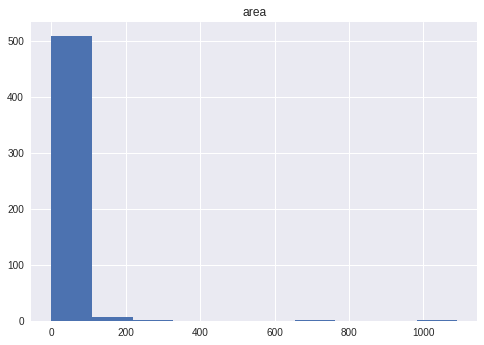

In [ ]:
df.hist(column='area')

In [ ]:
df['size_category'] = np.where(df['area']>1, '1', '0')
df.tail(10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,size_category
507,2,4,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0,0.00,0
508,1,2,aug,fri,91.0,166.9,752.6,7.1,25.9,41,3.6,0.0,0.00,0
509,5,4,aug,fri,91.0,166.9,752.6,7.1,21.1,71,7.6,1.4,2.17,1
510,6,5,aug,fri,91.0,166.9,752.6,7.1,18.2,62,5.4,0.0,0.43,0
511,8,6,aug,sun,81.6,56.7,665.6,1.9,27.8,35,2.7,0.0,0.00,0
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44,1
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29,1
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16,1
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00,0
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   X              517 non-null    int64  
 1   Y              517 non-null    int64  
 2   month          517 non-null    object 
 3   day            517 non-null    object 
 4   FFMC           517 non-null    float64
 5   DMC            517 non-null    float64
 6   DC             517 non-null    float64
 7   ISI            517 non-null    float64
 8   temp           517 non-null    float64
 9   RH             517 non-null    int64  
 10  wind           517 non-null    float64
 11  rain           517 non-null    float64
 12  area           517 non-null    float64
 13  size_category  517 non-null    object 
dtypes: float64(8), int64(3), object(3)
memory usage: 56.7+ KB


<AxesSubplot:xlabel='size_category', ylabel='count'>

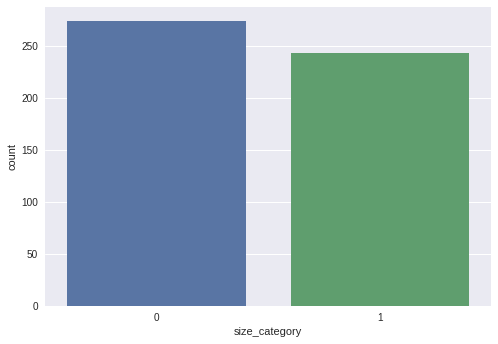

In [ ]:
sns.countplot(x="size_category", data=df)

In [ ]:
df['size_category']=pd.to_numeric(df['size_category'])

In [ ]:
print('Total Data:', df.shape[0])
print('Total Features:', df.shape[1])

Total Data: 517
Total Features: 14


In [ ]:
df.isnull().sum()

X                0
Y                0
month            0
day              0
FFMC             0
DMC              0
DC               0
ISI              0
temp             0
RH               0
wind             0
rain             0
area             0
size_category    0
dtype: int64

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
X,517.0,4.669246,2.313778,1.0,3.0,4.00,7.00,9.00
Y,517.0,4.299807,1.229900,2.0,4.0,4.00,5.00,9.00
FFMC,517.0,90.644681,5.520111,18.7,90.2,91.60,92.90,96.20
DMC,517.0,110.872340,64.046482,1.1,68.6,108.30,142.40,291.30
DC,517.0,547.940039,248.066192,7.9,437.7,664.20,713.90,860.60
ISI,517.0,9.021663,4.559477,0.0,6.5,8.40,10.80,56.10
temp,517.0,18.889168,5.806625,2.2,15.5,19.30,22.80,33.30
RH,517.0,44.288201,16.317469,15.0,33.0,42.00,53.00,100.00
wind,517.0,4.017602,1.791653,0.4,2.7,4.00,4.90,9.40
rain,517.0,0.021663,0.295959,0.0,0.0,0.00,0.00,6.40


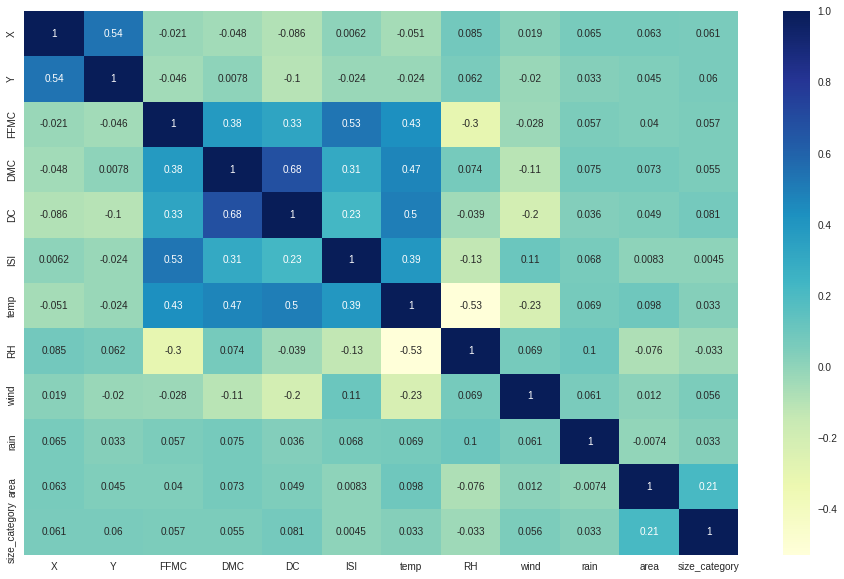

In [ ]:
fig, ax = plt.subplots(figsize=(16,10))  
dataplot = sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)
plt.show()

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Count plot of months')

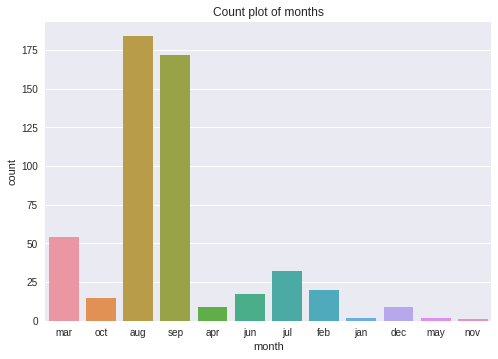

In [ ]:
sns.countplot(df['month'])
plt.title('Count plot of months')

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Count plot of seasons')

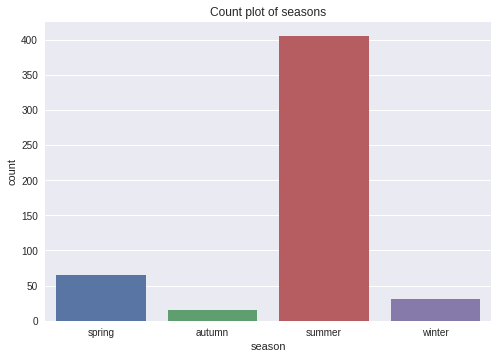

In [ ]:
# dictionary of months mapping to seasons
season_dict = {'dec' : 'winter', 'jan' : 'winter', 'feb' : 'winter',
              'mar' : 'spring', 'apr' : 'spring', 'may' : 'spring',
              'jun' : 'summer', 'jul' : 'summer', 'aug' : 'summer', 'sep' : 'summer',
              'oct' : 'autumn', 'nov' : 'autumn'}

# applying dictionary
df = df.replace({'month' : season_dict})

# renaming column
df = df.rename(columns = {'month' : 'season'})

# visualizing data
sns.countplot(df['season'])
plt.title('Count plot of seasons')

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Count plot of summer vs other seasons')

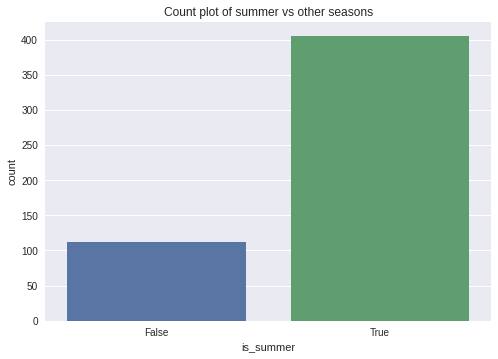

In [ ]:
# converting to is summer
df['season'] = (df['season'] == 'summer')

# renaming column
df = df.rename(columns = {'season' : 'is_summer'})

# visualizing data
sns.countplot(df['is_summer'])
plt.title('Count plot of summer vs other seasons')

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Count plot of days')

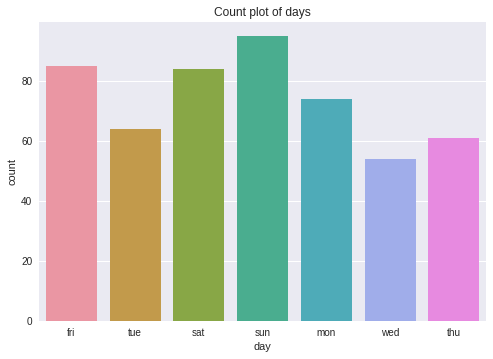

In [ ]:
sns.countplot(df['day'])
plt.title('Count plot of days')

/usr/local/lib/python3.9/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Count plot of weekend vs weekday')

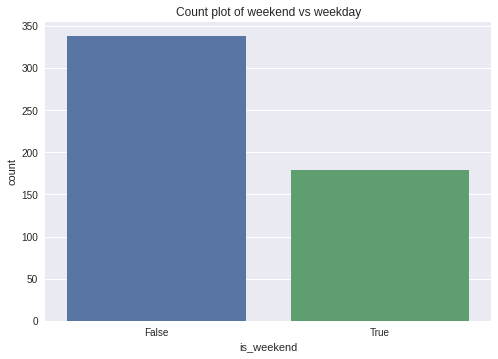

In [ ]:
# converting to is weekend
df['day'] = ((df['day'] == 'sun') | (df['day'] == 'sat'))

# renaming column
df = df.rename(columns = {'day' : 'is_weekend'})

# visualizing
sns.countplot(df['is_weekend'])
plt.title('Count plot of weekend vs weekday')

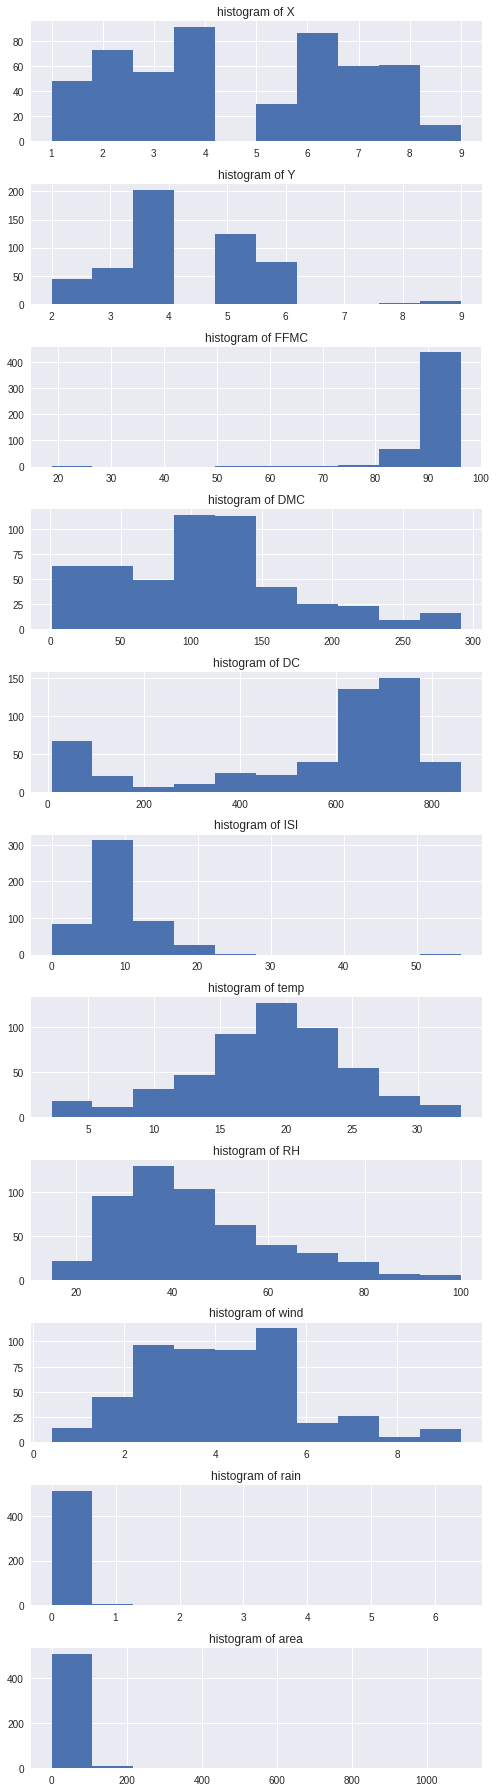

In [ ]:
# subplots
fig, ax = plt.subplots(11, figsize = (7,25))

# initial index
index = 0
unused_column = ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']

# visualizing
for column in unused_column:
    if column != 'is_summer':
        ax[index].hist(df[column])
        ax[index].title.set_text('histogram of ' + column)
        index += 1

# making plots visible
plt.tight_layout()

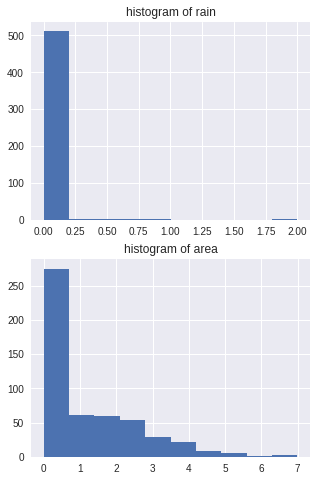

In [ ]:
#The distribution of the rain and area variables is too skewed and has outliers, then scaling the two variables will be done
# natural logarithm scaling (+1 to prevent errors at 0)
df.loc[:, ['rain', 'area']] = df.loc[:, ['rain', 'area']].apply(lambda x: np.log(x + 1), axis = 1)

# visualizing
fig, ax = plt.subplots(2, figsize = (5, 8))

ax[0].hist(df['rain'])
ax[0].title.set_text('histogram of rain')

ax[1].hist(df['area'])
ax[1].title.set_text('histogram of area')

features = y
labels = y.values.reshape(-1, 1)

In [ ]:
features = df.drop(['size_category'], axis = 1)
labels = df['size_category'].values.reshape(-1, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features,
                                                    labels,
                                                    test_size = 0.2,
                                                    random_state = 42)

In [ ]:
# fitting scaler
from sklearn.preprocessing import QuantileTransformer
sc_features = QuantileTransformer()


# transforming features
X_test = sc_features.fit_transform(X_test)
X_train = sc_features.transform(X_train)

/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (104). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:

# features
X_test = pd.DataFrame(X_test, columns = features.columns)
X_train = pd.DataFrame(X_train, columns = features.columns)

# labels
y_test = pd.DataFrame(y_test, columns = ['size_category'])
y_train = pd.DataFrame(y_train, columns = ['size_category'])

In [ ]:
X_train.head()

,X,Y,is_summer,is_weekend,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,0.412621,0.189320,1.0,1.0,0.621359,0.456311,0.883495,0.480583,0.796117,0.131068,0.524272,0.0,0.672079
1,0.412621,0.432039,1.0,0.0,0.320388,0.650485,0.660194,0.300971,0.378641,0.441748,0.150485,0.0,0.666078
2,0.189320,0.723301,1.0,0.0,0.592233,0.838956,0.521632,0.805825,0.548544,0.694175,0.524272,0.0,0.666667
3,0.300971,0.432039,1.0,0.0,1.000000,0.912621,0.592233,0.805825,1.000000,0.131068,0.150485,0.0,0.848720
4,0.519417,0.432039,0.0,1.0,0.100324,0.042431,0.043053,0.090615,0.121801,0.763754,0.150485,0.0,0.740291


In [ ]:
y_train

,size_category
0,1
1,1
2,1
3,1
4,1
...,...
408,0
409,0
410,0
411,0


In [ ]:

y_test

,size_category
0,0
1,0
2,1
3,1
4,1
...,...
99,1
100,1
101,1
102,1


In [ ]:
model = Sequential() # adding layers

In [ ]:
# input layer + 1st hidden layer
model.add(Dense(6, input_dim=13, activation='relu'))#according to the feature selection input_dim...
# 2nd hidden layer
model.add(Dense(6, activation='relu'))
# output layer
model.add(Dense(6, activation='sigmoid'))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'relu'))



In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 6)                 84        
                                                                 
 dense_1 (Dense)             (None, 6)                 42        
                                                                 
 dense_2 (Dense)             (None, 6)                 42        
                                                                 
 dropout (Dropout)           (None, 6)                 0         
                                                                 
 dense_3 (Dense)             (None, 1)                 7         
                                                                 
Total params: 175
Trainable params: 175
Non-trainable params: 0
_________________________________________________________________


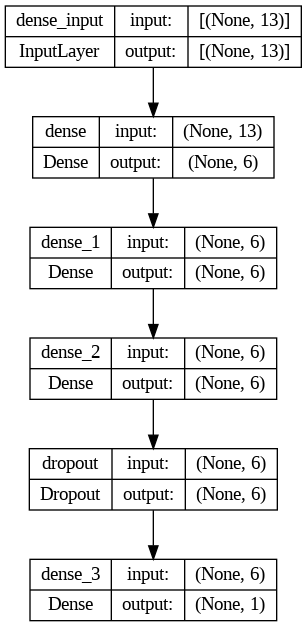

In [ ]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [ ]:
model.compile(optimizer = 'adam', metrics=['accuracy'], loss = 'binary_crossentropy')

In [ ]:
history = model.fit(X_train,
                    y_train,
                    validation_data = (X_test, y_test), 
                    batch_size = 10,
                    epochs = 100)

Epoch 1/100
42/42 [==============================] - 2s 9ms/step - loss: 5.1494 - accuracy: 0.5109 - val_loss: 4.2242 - val_accuracy: 0.5385
Epoch 2/100
42/42 [==============================] - 0s 3ms/step - loss: 2.6928 - accuracy: 0.5085 - val_loss: 0.9985 - val_accuracy: 0.5385
Epoch 3/100
42/42 [==============================] - 0s 3ms/step - loss: 3.0287 - accuracy: 0.4964 - val_loss: 0.9261 - val_accuracy: 0.5385
Epoch 4/100
42/42 [==============================] - 0s 3ms/step - loss: 2.5461 - accuracy: 0.5230 - val_loss: 0.8374 - val_accuracy: 0.5385
Epoch 5/100
42/42 [==============================] - 0s 3ms/step - loss: 2.2156 - accuracy: 0.5230 - val_loss: 0.7572 - val_accuracy: 0.5385
Epoch 6/100
42/42 [==============================] - 0s 3ms/step - loss: 2.0836 - accuracy: 0.5061 - val_loss: 0.6973 - val_accuracy: 0.5385
Epoch 7/100
42/42 [==============================] - 0s 4ms/step - loss: 1.8265 - accuracy: 0.5424 - val_loss: 0.6943 - val_accuracy: 0.5385
Epoch 8/100
4

In [ ]:
_, train_acc = model.evaluate(X_train, y_train, verbose=0)
_, valid_acc = model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Valid: %.3f' % (train_acc, valid_acc))

Train: 0.985, Valid: 0.962


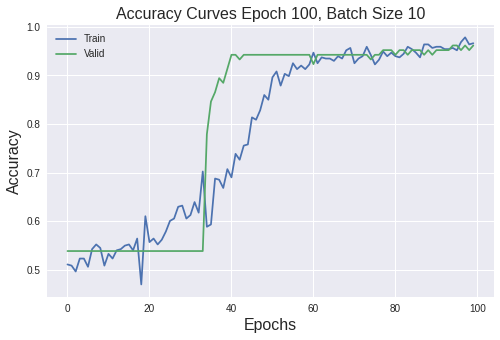

In [ ]:
plt.figure(figsize=[8,5])
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Valid')
plt.legend()
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves Epoch 100, Batch Size 10', fontsize=16)

plt.show()

Modeling removing X and Y

In [ ]:
features_coba = df.drop(['size_category','X','Y'], axis = 1)
labels_coba = df['size_category'].values.reshape(-1, 1)

In [ ]:

features_coba

,is_summer,is_weekend,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,False,False,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,False,False,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,False,True,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,False,False,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,False,True,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
512,True,True,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,True,True,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,True,True,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,True,True,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [ ]:
X_train_coba, X_test_coba, y_train_coba, y_test_coba = train_test_split(features_coba,
                                                                        labels_coba,
                                                                        test_size = 0.2,
                                                                        random_state = 42)

In [ ]:
# fitting scaler
from sklearn.preprocessing import QuantileTransformer
sc_features = QuantileTransformer()

# transforming features
X_test_coba = sc_features.fit_transform(X_test_coba)
X_train_coba = sc_features.transform(X_train_coba)

/usr/local/lib/python3.9/dist-packages/sklearn/preprocessing/_data.py:2627: UserWarning: n_quantiles (1000) is greater than the total number of samples (104). n_quantiles is set to n_samples.
  warnings.warn(


In [ ]:
# features
X_test_coba = pd.DataFrame(X_test_coba, columns = features_coba.columns)
X_train_coba = pd.DataFrame(X_train_coba, columns = features_coba.columns)

# labels
y_test_coba = pd.DataFrame(y_test_coba, columns = ['size_category'])
y_train_coba = pd.DataFrame(y_train_coba, columns = ['size_category'])

In [ ]:

X_train_coba.head()

,is_summer,is_weekend,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,1.0,1.0,0.621359,0.456311,0.883495,0.480583,0.796117,0.131068,0.524272,0.0,0.672079
1,1.0,0.0,0.320388,0.650485,0.660194,0.300971,0.378641,0.441748,0.150485,0.0,0.666078
2,1.0,0.0,0.592233,0.838956,0.521632,0.805825,0.548544,0.694175,0.524272,0.0,0.666667
3,1.0,0.0,1.000000,0.912621,0.592233,0.805825,1.000000,0.131068,0.150485,0.0,0.848720
4,0.0,1.0,0.100324,0.042431,0.043053,0.090615,0.121801,0.763754,0.150485,0.0,0.740291


In [ ]:
model_coba = Sequential()
     

In [ ]:

# input layer + 1st hidden layer
model_coba.add(Dense(6, input_dim=11, activation='relu'))
# 2nd hidden layer
model_coba.add(Dense(6, activation='relu'))
# output layer
model_coba.add(Dense(6, activation='sigmoid'))
model_coba.add(Dropout(0.2))
model_coba.add(Dense(1, activation = 'relu'))

In [ ]:

model_coba.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 6)                 72        
                                                                 
 dense_5 (Dense)             (None, 6)                 42        
                                                                 
 dense_6 (Dense)             (None, 6)                 42        
                                                                 
 dropout_1 (Dropout)         (None, 6)                 0         
                                                                 
 dense_7 (Dense)             (None, 1)                 7         
                                                                 
Total params: 163
Trainable params: 163
Non-trainable params: 0
_________________________________________________________________


In [ ]:
model_coba.compile(optimizer = 'adam', metrics=['accuracy'], loss = 'binary_crossentropy')

In [ ]:
history_coba = model_coba.fit(X_train_coba,
                    y_train_coba,
                    validation_data = (X_test_coba, y_test_coba), 
                    batch_size = 10,
                    epochs = 100)

Epoch 1/100
42/42 [==============================] - 1s 7ms/step - loss: 7.2190 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 2/100
42/42 [==============================] - 0s 3ms/step - loss: 7.2836 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 3/100
42/42 [==============================] - 0s 4ms/step - loss: 7.2847 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 4/100
42/42 [==============================] - 0s 4ms/step - loss: 7.2514 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 5/100
42/42 [==============================] - 0s 5ms/step - loss: 7.1638 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 6/100
42/42 [==============================] - 0s 4ms/step - loss: 7.0805 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 7/100
42/42 [==============================] - 0s 3ms/step - loss: 6.9201 - accuracy: 0.5278 - val_loss: 7.1192 - val_accuracy: 0.5385
Epoch 8/100
4

In [ ]:
_, train_acc_coba = model_coba.evaluate(X_train_coba, y_train_coba, verbose=0)
_, valid_acc_coba = model_coba.evaluate(X_test_coba, y_test_coba, verbose=0)
print('Train: %.3f, Valid: %.3f' % (train_acc_coba, valid_acc_coba))

Train: 0.528, Valid: 0.538


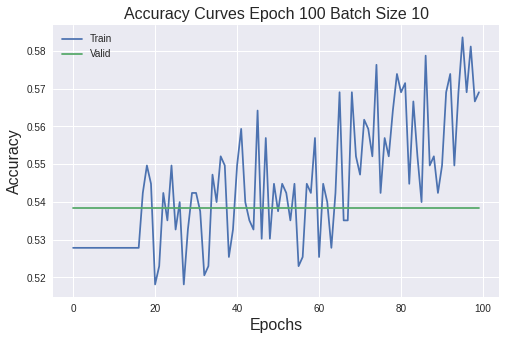

In [ ]:
plt.figure(figsize=[8,5])
plt.plot(history_coba.history['accuracy'], label='Train')
plt.plot(history_coba.history['val_accuracy'], label='Valid')
plt.legend()
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves Epoch 100 Batch Size 10', fontsize=16)

plt.show()

Batch Size = 4, 6, 10, 16, 32, 64, 128, 260

In [ ]:

X_train

,X,Y,is_summer,is_weekend,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,0.412621,0.189320,1.0,1.0,0.621359,0.456311,0.883495,0.480583,0.796117,0.131068,0.524272,0.0,0.672079
1,0.412621,0.432039,1.0,0.0,0.320388,0.650485,0.660194,0.300971,0.378641,0.441748,0.150485,0.0,0.666078
2,0.189320,0.723301,1.0,0.0,0.592233,0.838956,0.521632,0.805825,0.548544,0.694175,0.524272,0.0,0.666667
3,0.300971,0.432039,1.0,0.0,1.000000,0.912621,0.592233,0.805825,1.000000,0.131068,0.150485,0.0,0.848720
4,0.519417,0.432039,0.0,1.0,0.100324,0.042431,0.043053,0.090615,0.121801,0.763754,0.150485,0.0,0.740291
...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.412621,0.723301,1.0,0.0,0.868932,0.325243,0.728155,0.854369,0.378641,0.388350,0.436893,0.0,0.000000
409,0.412621,0.723301,0.0,0.0,0.436893,0.131160,0.082742,0.388350,0.398058,0.184466,0.334951,0.0,0.000000
410,0.189320,0.000000,1.0,0.0,0.592233,0.838956,0.521632,0.805825,0.703883,0.805825,0.334951,0.0,0.504854
411,0.189320,0.723301,1.0,1.0,0.305825,0.309503,0.232779,0.157497,0.800277,0.747573,0.077670,0.0,0.000000


In [ ]:
# Fit a model and plot learning curve
def fit_model(X_train, y_train, X_test, y_test, n_batch):
  # Define Model
  model = Sequential()
  model.add(Dense(6, input_dim=13, activation='relu'))
  model.add(Dense(6, activation='relu'))
  model.add(Dense(6, activation='sigmoid'))
  model.add(Dropout(0.2))
  model.add(Dense(1, activation = 'relu'))

  # Compile Model
  model.compile(optimizer = 'adam',
                metrics=['accuracy'],
                loss = 'binary_crossentropy')
  
  # Fit Model
  history = model.fit(X_train,
                      y_train,
                      validation_data=(X_test, y_test),
                      epochs=100,
                      verbose=0,
                      batch_size=n_batch)

  # Plot Learning Curves
  plt.plot(history.history['accuracy'], label='train') 
  plt.plot(history.history['val_accuracy'], label='test') 
  plt.title('batch='+str(n_batch)) 
  plt.legend()  

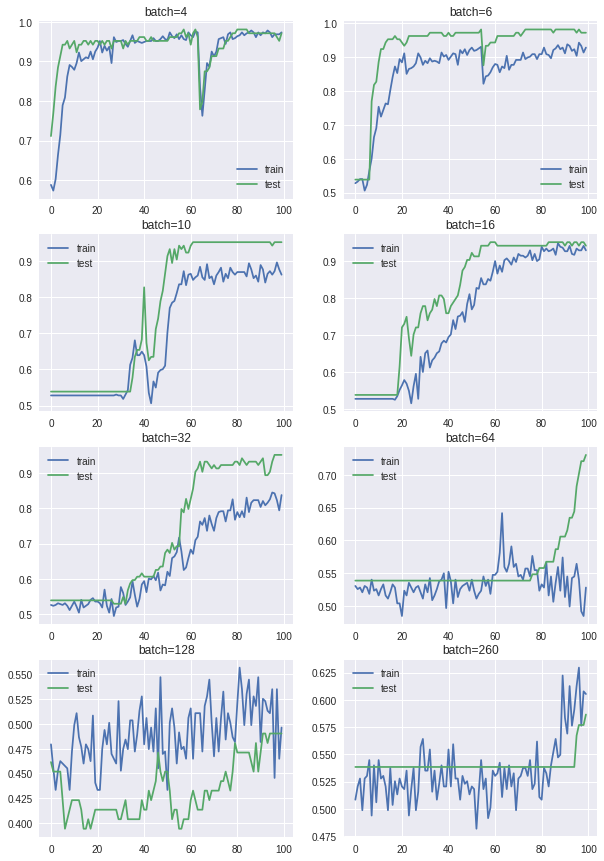

In [ ]:
# Create learning curves for different batch sizes
batch_sizes = [4, 6, 10, 16, 32, 64, 128, 260]

plt.figure(figsize=(10,15))
for i in range(len(batch_sizes)):

  # Determine the Plot Number
  plot_no = 420 + (i+1)
  plt.subplot(plot_no)

  # Fit model and plot learning curves for a batch size
  fit_model(X_train, y_train, X_test, y_test, batch_sizes[i])

# Show learning curves
plt.show()

Batch Size = 6, Epochs = 20, 50, 100, 120, 150, 200, 300, 400

In [ ]:
# fit a model and plot learning curve
def fit_model(trainX, trainy, validX, validy, n_epoch):
    
    # define model
    model = Sequential()
    model.add(Dense(6, input_dim=13, activation='relu'))
    model.add(Dense(6, activation='relu'))
    model.add(Dense(6, activation='sigmoid'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation = 'relu'))
    
    # compile model

    model.compile(optimizer ='adam',
                  metrics=['accuracy'],
                  loss = 'binary_crossentropy')
    
    # fit model
    history = model.fit(X_train,
                        y_train,
                        validation_data=(X_test, y_test),
                        epochs=n_epoch,
                        verbose=0,
                        batch_size=6)
    
    # plot learning curves
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='test')
    plt.title('epoch='+str(n_epoch))
    plt.legend()

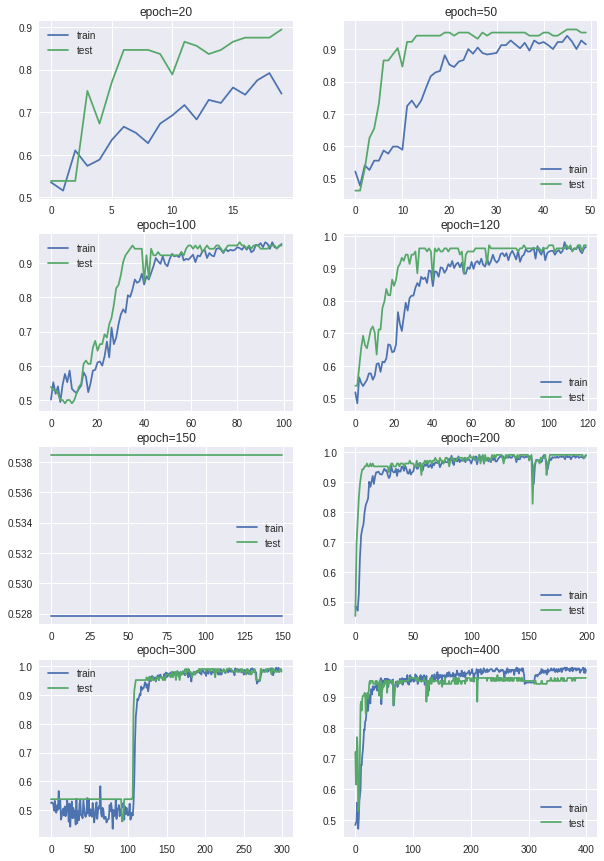

In [ ]:

# Create learning curves for different batch sizes
epochs = [20, 50, 100, 120, 150, 200, 300, 400]

plt.figure(figsize=(10,15))
for i in range(len(batch_sizes)):

  # Determine the Plot Number
  plot_no = 420 + (i+1)
  plt.subplot(plot_no)

  # Fit model and plot learning curves for a batch size
  fit_model(X_train, y_train, X_test, y_test, epochs[i])

# Show learning curves
plt.show()

Early Stopping

In [ ]:
def init_model():

    # define model
    model = Sequential()
    model.add(Dense(6, input_dim=13, activation='relu'))
    model.add(Dense(6, activation='relu'))
    model.add(Dense(6, activation='sigmoid'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation = 'relu'))
    
    model.compile(optimizer ='adam',
                  metrics=['accuracy'],
                  loss = 'binary_crossentropy')
    
    return model
     

# init model
model = init_model()
     

# simple early stopping
es = EarlyStopping(monitor='val_loss',
                   mode='min',
                   verbose=1,
                   patience=150)
     

mc = ModelCheckpoint('best_model.h5',
                     monitor='val_accuracy',
                     mode='max',
                     verbose=1,
                     save_best_only=True)
history = model.fit(X_train,
                    y_train,
                    validation_data=(X_test, y_test),
                    epochs=250,
                    verbose=0,
                    batch_size=6,
                    callbacks=[es, mc])




Epoch 1: val_accuracy improved from -inf to 0.53846, saving model to best_model.h5

Epoch 2: val_accuracy did not improve from 0.53846

Epoch 3: val_accuracy did not improve from 0.53846

Epoch 4: val_accuracy did not improve from 0.53846

Epoch 5: val_accuracy did not improve from 0.53846

Epoch 6: val_accuracy did not improve from 0.53846

Epoch 7: val_accuracy did not improve from 0.53846

Epoch 8: val_accuracy did not improve from 0.53846

Epoch 9: val_accuracy did not improve from 0.53846

Epoch 10: val_accuracy did not improve from 0.53846

Epoch 11: val_accuracy did not improve from 0.53846

Epoch 12: val_accuracy did not improve from 0.53846

Epoch 13: val_accuracy did not improve from 0.53846

Epoch 14: val_accuracy did not improve from 0.53846

Epoch 15: val_accuracy did not improve from 0.53846

Epoch 16: val_accuracy did not improve from 0.53846

Epoch 17: val_accuracy did not improve from 0.53846

Epoch 18: val_accuracy did not improve from 0.53846

Epoch 19: val_accuracy

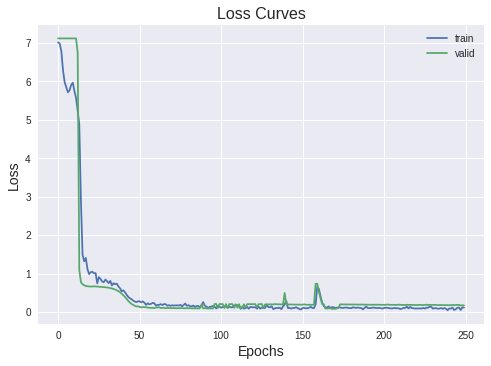

In [ ]:
# plot training history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.legend()
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Loss Curves', fontsize=16)
plt.show()

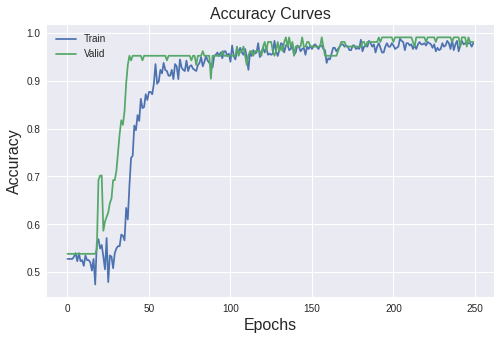

In [ ]:

plt.figure(figsize=[8,5])
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Valid')
plt.legend()
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Accuracy', fontsize=16)
plt.title('Accuracy Curves', fontsize=16)

plt.show()

In [ ]:
from keras.models import load_model
model = load_model('best_model.h5')
     

_, train_acc = model.evaluate(X_train, y_train, verbose=0)
_, valid_acc = model.evaluate(X_test, y_test, verbose=0)
print('Train: %.3f, Valid: %.3f' % (train_acc, valid_acc))

Train: 0.983, Valid: 0.990
